# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [1]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, MinMaxScaler

In [2]:
print(torch.__version__)
print(torch._dynamo.__file__)

2.6.0+cu124
/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/torch/_dynamo/__init__.py


In [32]:
EPOCHS = 600
SEED = 40

STD = 0.02
COPY = 5
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.1

# Set BATCH_SIZE to the full training dataset size for now
# BATCH_SIZE = len(X_train)
LR = 1e-3

N_FOLDS = 5

In [4]:
df = pd.read_csv("data/Glove_v2/output.csv")
df = df.drop(columns=["0"], errors='ignore')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22683 entries, 0 to 22682
Data columns (total 49 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       22683 non-null  float64
 1   2       22683 non-null  float64
 2   3       22683 non-null  float64
 3   4       22683 non-null  float64
 4   5       22683 non-null  float64
 5   6       22683 non-null  float64
 6   7       22683 non-null  float64
 7   8       22683 non-null  float64
 8   9       22683 non-null  float64
 9   10      22683 non-null  float64
 10  11      22683 non-null  float64
 11  12      22683 non-null  float64
 12  13      22683 non-null  float64
 13  14      22683 non-null  float64
 14  15      22683 non-null  float64
 15  16      22683 non-null  float64
 16  17      22683 non-null  float64
 17  18      22683 non-null  float64
 18  19      22683 non-null  float64
 19  20      22683 non-null  float64
 20  21      22683 non-null  float64
 21  22      22683 non-null  float64
 22  23      2

In [5]:
# # def augment_with_noise(df, label_col="label", noise_std=0.01, copies=3):
#     feature_cols = df.drop(columns=[label_col]).columns
#     augmented_dfs = [df]  # keep original

#     for i in range(copies):

#         noisy_df = df.copy()

#         noise = np.random.normal(
#             loc=0,
#             scale=noise_std,
#             size=noisy_df[feature_cols].shape
#         )

#         noisy_df[feature_cols] = noisy_df[feature_cols] + noise

#         augmented_dfs.append(noisy_df)

#     return pd.concat(augmented_dfs, ignore_index=True)

In [6]:
def augment_with_noise(df, label_col="label", noise_fraction=0.05, copies=3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    # Isolate only numeric columns, ignoring the label
    features_df = df.drop(columns=[label_col], errors='ignore')
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    
    augmented_dfs = [df]  # keep original

    # Calculate the standard deviation for each numeric column
    col_stds = df[numeric_cols].std().values

    for _ in range(copies):
        noisy_df = df.copy()
        
        # Generate noise proportional to each column's standard deviation
        noise = np.random.normal(
            loc=0,
            scale=col_stds * noise_fraction, 
            size=(len(df), len(numeric_cols))
        )
        
        noisy_df[numeric_cols] = noisy_df[numeric_cols] + noise
        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

In [7]:
# 1. Split FIRST to prevent data leakage. 
# stratify=df['label'] ensures the 1000 test rows have the correct class proportions.
df_train, testing = train_test_split(df, test_size=1000, stratify=df['label'], random_state=42)

# Reset indices for cleanliness
df_train = df_train.reset_index(drop=True)
testing = testing.reset_index(drop=True)

# 2. Balance the TRAINING data only
min_count = df_train['label'].value_counts().min()
df_balanced = df_train.groupby('label').sample(n=min_count, random_state=42).reset_index(drop=True)

print("Balanced Training Class Counts:")
print(df_balanced['label'].value_counts())

# Now 'df_balanced' is ready for your augment_with_noise() function!
df = df_balanced

Balanced Training Class Counts:
label
none        686
paper       686
rock        686
scissors    686
Name: count, dtype: int64


In [8]:

# Print original size with context
print(f"Original row count: {len(df)}")

augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_fraction=0.05, # Using the updated parameter from the previous cell
    copies=COPY,
    random_state=42      # Using the new reproducibility parameter
)

print(f"Augmented row count: {len(augmented_df)}")

# If you must overwrite df to save memory, do it at the very end
df = augmented_df

Original row count: 2744
Augmented row count: 16464


In [9]:
df.head()

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,label
0,0.374,0.907,-0.104,1.567,-0.783,-0.448,-0.088,-0.412,-0.089,0.453,...,4.779,1.786,1.099,0.743,0.365,-0.749,-6.168,-2.611,1.298,none
1,0.318,0.861,-0.328,-3.469,9.624,-4.476,-0.192,-0.406,0.000,0.114,...,7.130,-1.206,-0.870,0.754,0.227,-0.787,-3.527,-6.168,-1.985,none
2,0.345,0.912,-0.203,5.036,-1.567,1.007,-0.084,-0.425,-0.048,0.417,...,4.458,4.595,0.473,0.760,0.260,-0.753,-6.855,-0.489,0.763,none
3,0.224,0.928,-0.270,-0.112,2.350,-0.560,-0.062,-0.439,-0.023,0.234,...,5.542,1.985,-1.740,0.802,0.219,-0.727,-4.916,-3.130,-1.359,none
4,0.334,0.916,-0.184,0.112,-0.895,0.336,-0.073,-0.422,-0.047,0.409,...,4.290,0.641,-0.427,0.772,0.259,-0.775,-6.351,-4.168,0.046,none


In [ ]:
# testing = df.sample(n=1000, random_state=42)
# df      = df.drop(testing.index).reset_index(drop=True)
# testing = testing.sort_values(by='label').reset_index(drop=True)

# min_count = df['label'].value_counts().min()

# # The modern, clean way to balance (undersample) classes in Pandas
# df_balanced = df.groupby('label').sample(n=min_count, random_state=42)

# # If you want a fresh index from 0 to N without losing your columns:
# df_balanced = df_balanced.reset_index(drop=True)

# # This will now work perfectly
# print(df_balanced['label'].value_counts())

# df = df_balanced

label
none        4196
paper       4196
rock        4196
scissors    4196
Name: count, dtype: int64


In [10]:
df_train  = df
df_train.label.value_counts()

label
none        4116
paper       4116
rock        4116
scissors    4116
Name: count, dtype: int64

## Make data and label dfs


In [11]:
# Scramble the rows
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_train.head(3)

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,label
0,0.306013,0.859959,-0.313860,-1.309676,6.101842,-2.824779,-0.148804,-0.445608,-0.041167,0.192426,...,4.041847,0.268605,-1.171098,0.726843,0.196894,-0.824972,-0.237730,-5.656582,-0.788875,none
1,-0.207266,0.857795,-0.373309,16.376166,-8.359806,-2.192433,-0.027380,-0.293192,0.129726,-0.377990,...,1.967296,6.216031,9.023419,1.029877,-0.224641,-0.075250,-7.549133,3.558161,7.209644,rock
2,0.328365,0.915633,-0.197195,-1.232017,-3.009591,2.521137,-0.082003,-0.433987,-0.045598,0.346588,...,6.546872,0.033855,-3.090769,0.777137,0.253788,-0.791944,-7.443093,-5.190780,-0.399154,none


In [12]:
# Select only columns that contain text (strings or objects)
text_cols = df_train.select_dtypes(include=['object', 'string']).columns

# Strip leading and trailing whitespace from those columns
df_train[text_cols] = df_train[text_cols].apply(lambda x: x.str.strip())

In [13]:
# 1. Get all unique labels and sort them alphabetically to guarantee consistency
unique_labels = sorted(df_train["label"].unique())

# 2. Dynamically generate the dictionary using enumerate
mapping = {label: idx for idx, label in enumerate(unique_labels)}

# Print the mapping so you know exactly what the model is learning!
print(f"Dynamic mapping generated: {mapping}")

y_train = df_train["label"].map(mapping)

# 2. Safety check: Ensure no labels were misspelled and turned into NaNs
if y_train.isna().any():
    print("WARNING: Some labels were not in the mapping dictionary and became NaN!")
    print(df_train[y_train.isna()]['label'].unique()) # Show the problem labels

# 3. Separate the features (X) from the labels (y)
X_train = df_train.drop(columns=["label"])

Dynamic mapping generated: {'none': 0, 'paper': 1, 'rock': 2, 'scissors': 3}


In [14]:
# torch.tensor() creates a clean copy, removing the read-only warning
# .to_numpy() is the modern pandas standard
X = torch.tensor(X_train.to_numpy()).type(torch.float)
y = torch.tensor(y_train.to_numpy()).type(torch.long)

# Split data into train and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X,
    y,
    test_size=0.2, 
    stratify=y,       
    random_state=42
)

print(f"Training rows: {len(X_train_final)}, Validation rows: {len(X_val)}")

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Training rows: 13171, Validation rows: 3293
Using device: cuda


# Model

In [15]:
# Dynamically get input features from your PyTorch training tensor
input_features = X_train_final.shape[1]

# Dynamically count the number of unique classes from your label tensor
classes = len(torch.unique(y_train_final))

# Set hidden units (assuming HIDDEN is defined earlier)
hidden_units = HIDDEN

# Clearly print the architecture parameters
print(f"Input features: {input_features}")
print(f"Output classes: {classes}")
print(f"Hidden units: {hidden_units}")

Input features: 48
Output classes: 4
Hidden units: 0


In [16]:
# MODEL 4
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=32),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=16, out_features=output_features)
        )

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        return self.linear_layer_stack(x)

In [33]:
# Create an instance of the model and send it to target device
model_4 = RPSModel(
    input_features=input_features, 
    output_features=classes
).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer (Upgraded to Adam for faster/better convergence)
optimizer = optim.Adam(params=model_4.parameters(), lr=LR)

# Calculate accuracy with a device-safety check
def accuracy_fn(y_true, y_pred):
    # Ensure both tensors are on the same device before comparing
    if y_true.device != y_pred.device:
        y_pred = y_pred.to(y_true.device)
        
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [34]:
# Set the seed if you want the exact same "random" number every time
random.seed(42) 

random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 82


In [35]:
# 1. Use the corrected variable names from our earlier split
X_train_tensor, y_train_tensor = X_train_final.to(device), y_train_final.to(device)
X_val_tensor, y_val_tensor = X_val.to(device), y_val.to(device)

# 2. Create a DataLoader for Mini-Batch training
# A batch size of 32 or 64 is standard for tabular data
BATCH_SIZE = 1024
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

torch.manual_seed(SEED)
epochs = EPOCHS
train_losses, val_losses = [], []

for epoch in range(epochs):
    ### Training Phase
    model_4.train()
    total_train_loss, total_train_acc = 0, 0
    
    # Loop through the data in batches!
    for batch_X, batch_y in train_dataloader:
        y_logits = model_4(batch_X) 
        y_pred = torch.argmax(y_logits, dim=1)
        
        loss = loss_fn(y_logits, batch_y)
        acc = accuracy_fn(y_true=batch_y, y_pred=y_pred) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_acc += acc
        
    # Average loss and accuracy across all batches
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)

    ### Evaluation Phase (Validation Set)
    model_4.eval()
    with torch.inference_mode():
        # Validation can usually handle the full dataset at once if it fits in memory
        val_logits = model_4(X_val_tensor)
        val_pred = torch.argmax(val_logits, dim=1)
        
        val_loss = loss_fn(val_logits, y_val_tensor)
        val_acc = accuracy_fn(y_true=y_val_tensor, y_pred=val_pred)

    # Record losses
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {avg_train_loss:.5f}, Train Acc: {avg_train_acc:.2f}% | Val loss: {val_loss:.5f}, Val acc: {val_acc:.2f}%")

Epoch: 0 | Train Loss: 1.52928, Train Acc: 29.30% | Val loss: 1.32026, Val acc: 36.77%
Epoch: 10 | Train Loss: 0.66402, Train Acc: 81.34% | Val loss: 0.52055, Val acc: 92.20%
Epoch: 20 | Train Loss: 0.26494, Train Acc: 92.76% | Val loss: 0.14615, Val acc: 96.63%
Epoch: 30 | Train Loss: 0.15401, Train Acc: 95.91% | Val loss: 0.07539, Val acc: 98.57%
Epoch: 40 | Train Loss: 0.10831, Train Acc: 97.17% | Val loss: 0.05244, Val acc: 98.91%
Epoch: 50 | Train Loss: 0.09072, Train Acc: 97.61% | Val loss: 0.04142, Val acc: 99.09%
Epoch: 60 | Train Loss: 0.07562, Train Acc: 98.09% | Val loss: 0.03639, Val acc: 99.06%
Epoch: 70 | Train Loss: 0.06734, Train Acc: 98.22% | Val loss: 0.03161, Val acc: 99.24%
Epoch: 80 | Train Loss: 0.05887, Train Acc: 98.49% | Val loss: 0.02801, Val acc: 99.30%
Epoch: 90 | Train Loss: 0.05073, Train Acc: 98.67% | Val loss: 0.02617, Val acc: 99.42%
Epoch: 100 | Train Loss: 0.05060, Train Acc: 98.60% | Val loss: 0.02454, Val acc: 99.45%
Epoch: 110 | Train Loss: 0.04791

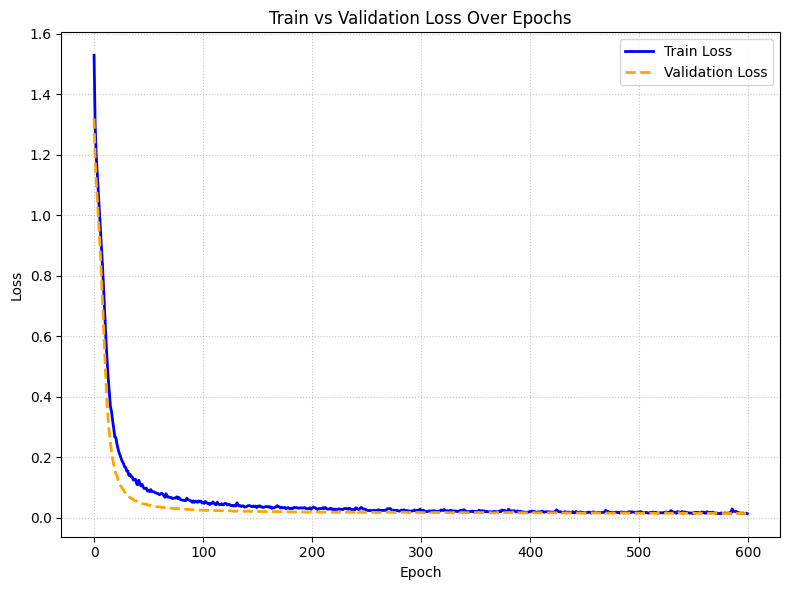

In [36]:
plt.figure(figsize=(8, 6))

# Updated to use val_losses to match the previous cell's corrections!
plt.plot(train_losses, label="Train Loss", color='blue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='orange', linewidth=2, linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss Over Epochs")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Testing

In [38]:
# 1. Safely copy the test set to avoid modifying the original data
testing_prep = testing.copy()

# 2. Apply the dynamic mapping we generated earlier
testing_prep["label"] = testing_prep["label"].map(mapping)

# 3. Setup Visualization Constants
# Define display labels FIRST
display_labels = ["Rock", "Paper", "Scissors", "None"]
num_classes = len(display_labels)

# Use modern matplotlib syntax
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Generate exactly 4 colors based on the length of your display labels
colors = cmap(np.linspace(0, 1, num_classes))

# Set confidence threshold for predictions
conf_thres = 0.7

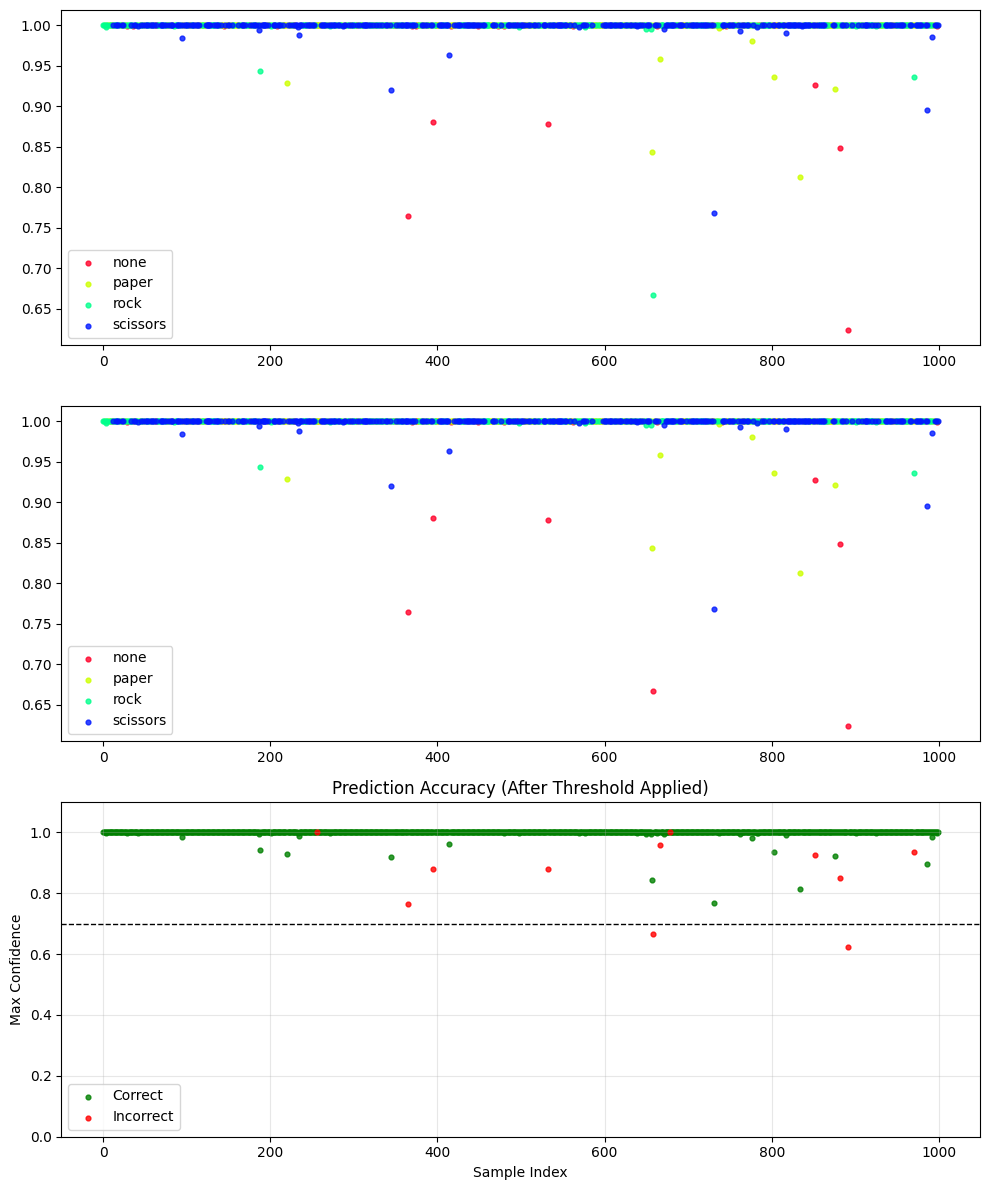

In [39]:
# ------------------------
# Prepare Test Features
# ------------------------
true_labels1 = testing_prep['label'] # Using the safely copied dataframe from the previous cell
X_features = testing_prep.drop(columns=['label'])

# Vectorized coercion (much faster than a for loop)
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# Align columns with the training data's features (Update the variable name here if needed)
# Use the pandas DataFrame from earlier in your pipeline
X_features = X_features[X_train.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert to numpy for matplotlib and thresholding
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric1 = true_labels1.reset_index(drop=True).values

# ------------------------
# Prepare thresholded predictions (FIXED LOGIC)
# ------------------------
pred_classes_thresh = max_classes.copy()

# Look up the actual integer mapped to 'none' in your dictionary (it should be 3)
existing_none_idx = mapping.get('none', 3) 

# If confidence is below threshold, set prediction to the existing 'none' class
pred_classes_thresh[max_probs < conf_thres] = existing_none_idx

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Ensure max_classes is integers, not floats
max_classes = max_classes.astype(int)
pred_classes_thresh = pred_classes_thresh.astype(int)

# ------------------------
# Plot 1: Updated Loop
# ------------------------
for label, class_idx in mapping.items(): # mapping.items() gives (str, int)
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    
    # We use the label in the scatter call so the legend picks it up
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax1.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, # This is what the legend looks for!
            color=color
        )

# Check if anything was actually plotted before calling legend to avoid the warning
if ax1.get_legend_handles_labels()[0]:
    ax1.legend()

# ------------------------
# Plot 2: Updated Loop
# ------------------------
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax2.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, 
            color=color
        )

if ax2.get_legend_handles_labels()[0]:
    ax2.legend()
# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric1
incorrect_mask_thresh = pred_classes_thresh != true_numeric1

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(correct_idx, max_probs[correct_idx], s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(incorrect_idx, max_probs[incorrect_idx], s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold Applied)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Live Data Sim

In [56]:
# 1. Load and clean
df_test = pd.read_csv("data/Glove_v2/jag_rps_test_2.csv", sep=",")
df_test = df_test.iloc[1:].copy() # Use .copy() to avoid SettingWithCopyWarnings

# 2. Safe dropping and renaming
# Replace '0' with the actual column name if it's a string like "Time"
df_test = df_test.drop(columns=[df_test.columns[0]], errors='ignore') 
df_test.rename(columns={df_test.columns[-1]: 'label'}, inplace=True)

# 3. Bulletproof label mapping
mapping2 = {'rock': 0, 'paper': 1, 'scissors': 2, 'none': 3}
df_test["label"] = df_test["label"].astype(str).str.strip().str.lower().map(mapping2)

# 4. Visualization Setup (ORDER MATTERS!)
display_labels = ["Rock", "Paper", "Scissors", "None"]
num_classes = len(display_labels)
conf_thres = 0.7

# Generate exactly 4 colors
cmap = plt.colormaps.get_cmap("gist_rainbow")
colors = cmap(np.linspace(0, 1, num_classes))

# Assign to your testing variable
testing2 = df_test

In [57]:
df_test.head(20)

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,label
1,0.748,-0.312,-0.549,9.960,1.567,17.010,-0.229,0.030,0.405,0.945,...,5.802,0.504,-2.198,0.422,0.816,0.461,-5.588,-4.244,-1.695,3
2,0.756,-0.321,-0.541,1.119,0.448,0.783,-0.239,0.024,0.441,0.898,...,5.603,0.672,-2.046,0.417,0.813,0.457,-5.725,-4.321,-1.252,3
3,0.751,-0.325,-0.533,0.112,-0.224,0.224,-0.235,0.014,0.433,0.894,...,5.359,0.076,-1.099,0.422,0.814,0.460,-5.786,-5.069,-0.382,3
4,0.751,-0.317,-0.537,-0.112,-0.224,0.224,-0.250,0.031,0.433,0.894,...,5.038,0.153,-1.695,0.425,0.810,0.459,-5.985,-4.687,-0.702,3
5,0.748,-0.321,-0.541,-0.224,-0.112,0.224,-0.247,0.021,0.425,0.890,...,5.634,0.336,-0.977,0.420,0.805,0.463,-5.588,-5.023,-0.443,3
6,0.752,-0.321,-0.541,-0.224,0.224,0.224,-0.242,0.031,0.437,0.894,...,5.450,0.351,-2.092,0.422,0.809,0.462,-5.802,-4.550,-1.176,3
7,0.752,-0.321,-0.537,-0.112,0.224,0.000,-0.236,0.034,0.425,0.890,...,5.695,0.290,-1.450,0.419,0.809,0.461,-5.405,-4.748,-0.779,3
8,0.752,-0.325,-0.541,-0.112,-0.112,-0.224,-0.239,0.028,0.437,0.894,...,5.588,0.244,-1.710,0.421,0.811,0.461,-5.695,-4.718,-0.947,3
9,0.752,-0.321,-0.537,0.224,0.560,0.336,-0.239,0.013,0.424,0.890,...,6.015,0.397,-1.634,0.418,0.810,0.459,-5.389,-4.824,-1.130,3
10,0.756,-0.321,-0.537,0.112,0.112,0.448,-0.246,0.021,0.437,0.898,...,5.420,1.069,-1.634,0.420,0.816,0.461,-5.939,-4.519,-1.130,3


In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Separate features and labels from df_test
# features_to_scale = testing2.drop(columns=['label'])
# labels_df_test = testing2['label']

# Initialize MinMaxScaler
# scaler = MinMaxScaler()

# Fit and transform the features
# scaled_features = scaler.fit_transform(features_to_scale)

# Create a DataFrame with the scaled features
# df_test_normalized = pd.DataFrame(scaled_features, columns=features_to_scale.columns)

# Add the label column back to the normalized DataFrame
# df_test_normalized['label'] = labels_df_test.reset_index(drop=True)

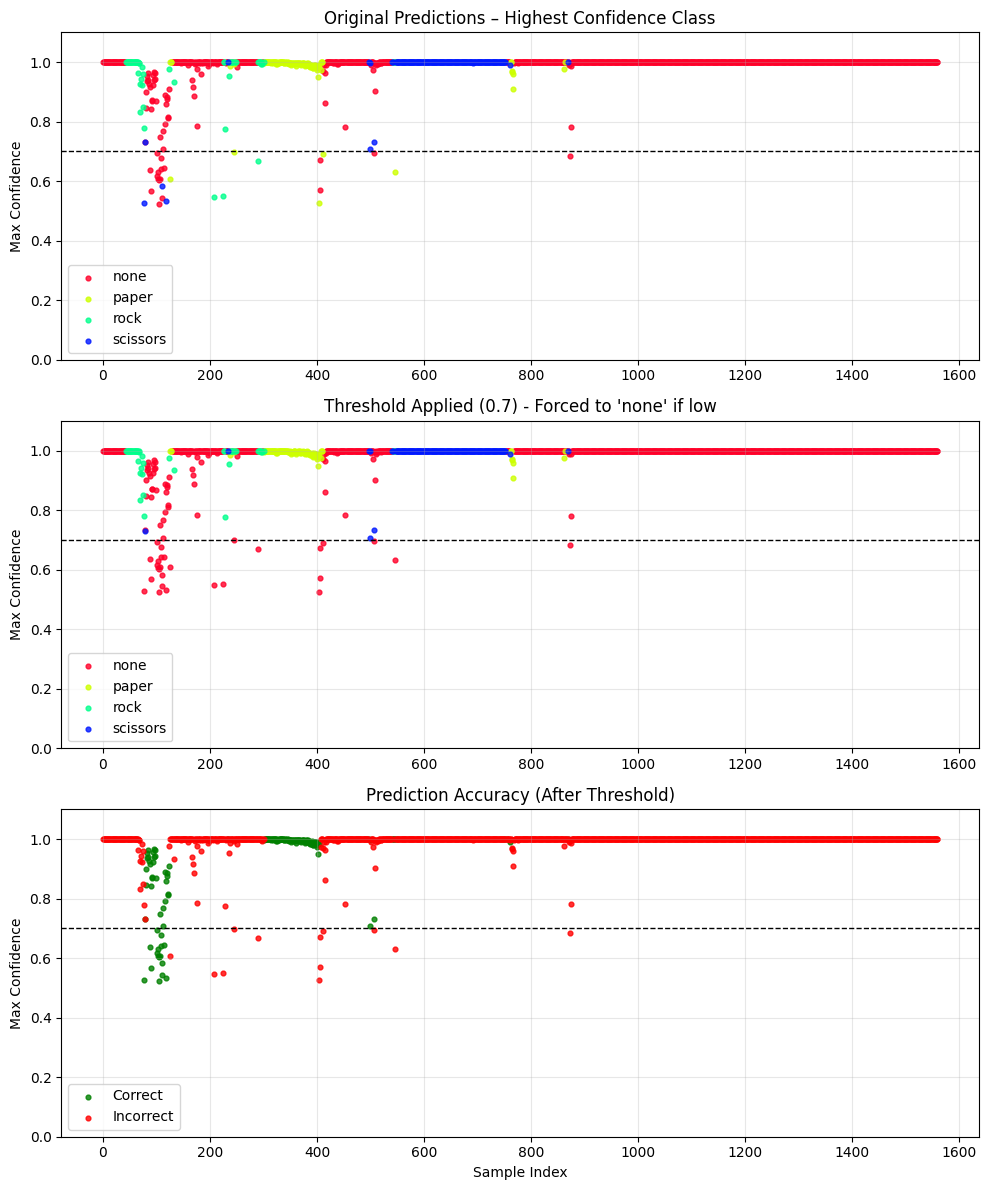

In [58]:
# ------------------------
# 1. Prepare Test Features
# ------------------------
# Use the testing2 dataframe we loaded from the new CSV
true_labels2 = testing2["label"]
X_features = testing2.drop(columns=['label'], errors='ignore')

# Vectorized coercion to ensure all sensor data is numeric
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# CRITICAL: Align columns with your ORIGINAL training features
# Replace 'X_train' with whatever your training DataFrame was named (e.g., 'df_train' or 'data')
X_features = X_features[X_train.columns] 

# Convert to PyTorch tensor and move to GPU/CPU
X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# 2. Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert tensors to CPU numpy for thresholding and plotting
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy().astype(int)
true_numeric2 = true_labels2.reset_index(drop=True).values.astype(int)

# ------------------------
# 3. Thresholding Logic (Fixed)
# ------------------------
pred_classes_thresh = max_classes.copy()
# Map low confidence to the EXISTING 'none' index (usually 3)
none_class_idx = mapping.get('none', 3) 
pred_classes_thresh[max_probs < conf_thres] = none_class_idx

# ------------------------
# 4. Visualization (3 Subplots)
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Plot 1: Raw Predictions
for label, class_idx in mapping.items():
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax1.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0, 1.1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Thresholded predictions
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax2.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0, 1.1)
ax2.set_title(f"Threshold Applied ({conf_thres}) - Forced to 'none' if low")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Accuracy (Correct vs Incorrect)
correct_mask = (pred_classes_thresh == true_numeric2)
incorrect_mask = (pred_classes_thresh != true_numeric2)

ax3.scatter(np.flatnonzero(correct_mask), max_probs[correct_mask], 
            s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(np.flatnonzero(incorrect_mask), max_probs[incorrect_mask], 
            s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation


## Confusion Matrix

In [44]:
true_numeric = true_numeric2

In [45]:
print(f"Number of NaNs in true_numeric: {np.isnan(true_numeric).sum()}")

Number of NaNs in true_numeric: 0


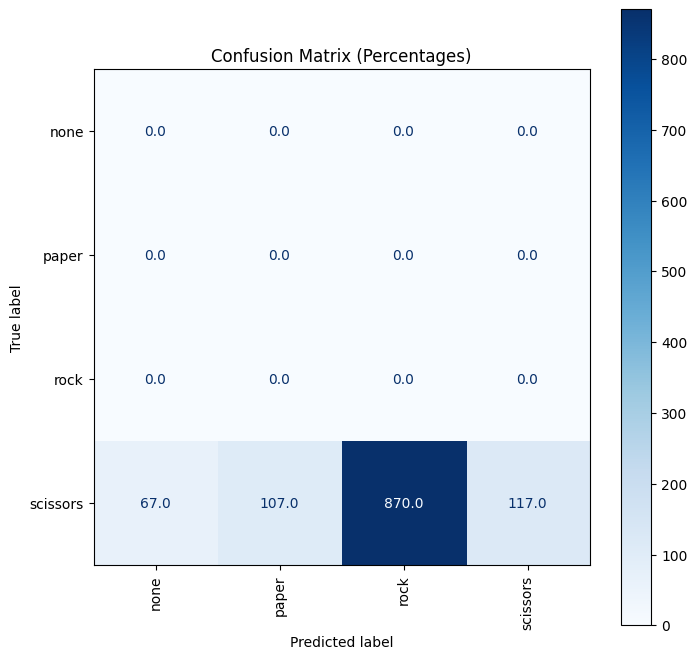

In [46]:
# 1. Ensure numeric types and clean NaNs
valid_mask = ~np.isnan(true_numeric2) # Using 'true_numeric2' from your latest test
true_numeric_clean = true_numeric2[valid_mask].astype(int)
max_classes_clean = max_classes[valid_mask].astype(int)

# 2. Calculate the matrix
# Use 'labels' to force the matrix to include all classes even if they weren't predicted
class_indices = list(range(len(mapping)))
cm = confusion_matrix(true_numeric_clean, max_classes_clean, labels=class_indices)

# 3. Plot with normalization ('true' normalizes by rows/actual classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=list(mapping.keys())
)

# Plotting with percentages makes it much easier to read
disp.plot(cmap='Blues', ax=ax, values_format='.1f', xticks_rotation='vertical')

plt.title("Confusion Matrix (Percentages)")
plt.show()

In [ ]:
all_labels_for_confidence = list(mapping.keys()) + ['none'] # Use all_labels which includes 'none'

print("Average Confidence per Predicted Class (including 'none'):\n")
for class_idx, class_name in enumerate(all_labels_for_confidence):
    # Filter predictions that belong to the current class (including 'none')
    # Use pred_classes_thresh which contains the 'none' class index
    class_mask = (pred_classes_thresh == class_idx)

    # Get the confidence scores for the samples predicted as this class
    # For 'none' class, the confidence is still derived from max_probs before thresholding
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize()}: {avg_confidence:.4f}")
    else:
        print(f"{class_name.capitalize()}: No predictions for this class.")

Average Confidence per Predicted Class (including 'none'):

Rock: 0.9628
Paper: 0.9771
Scissors: 0.9774
None: No predictions for this class.
None: 0.5427


In [ ]:
true_labels = true_numeric2 # Get the mapped labels from the 'testing' DataFrame

X_features = testing2.copy()
X_features = X_features.drop(columns=['label']) # Drop label first

# Ensure all columns are numeric, coercing errors to NaN and filling NaNs with 0
for col in X_features.columns:
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')
X_features = X_features.fillna(0)

# Align columns with the training data's features
X_features.columns = data.columns

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device) # 'device' must be globally available

# Inference to get new_probs (from H63ieaXWK1ym)
model_4.eval() # 'model_4' must be globally available and trained
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)

# Define true_numeric (from lhpHLBauRpGJ)
true_numeric = true_labels

# Convert true_numeric to one-hot encoded format for OvR ROC AUC calculation
label_binarizer = LabelBinarizer().fit(true_numeric)
y_onehot_test = label_binarizer.transform(true_numeric)
y_score = new_probs.cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))

# Get class names from mapping
class_names = list(mapping.keys())

# Plot ROC curve for each class
for class_id in range(len(class_names)):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {class_names[class_id]}",
        ax=ax,
        plot_chance_level=False,
    )

# Add chance level line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)

ax.set_title("One-vs-Rest ROC curves for multi-class data")
ax.legend(loc="lower right")
plt.show()

/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/sklearn/externals/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y contains NaN.

## K-Fold

In [ ]:

torch.manual_seed(SEED)

all_train_losses = [] # Initialize to store epoch-wise train losses for each fold
all_test_losses  = [] # This will now store epoch-wise test losses for each fold

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_train_accs = [] # Initialize to store final train accuracy for each fold
fold_test_accs = [] # This will store final test accuracy for each fold

# Initialize lists to store per-fold metrics
fold_precisions = []
fold_recalss = []
fold_f1_scores = []

X_np = X.numpy()
y_np = y.numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\n{'='*40}")
    print(f"  FOLD {fold + 1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Split data for the current fold
    X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
    X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

    # Create a new model for each fold to ensure independent training
    model = RPSModel(input_features=input_features,
                     output_features=classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1) # Optimizer needs to be re-initialized too

    train_losses_per_epoch_fold = [] # To store losses for current fold's training
    test_losses_per_epoch_fold = []  # To store losses for current fold's testing
    current_fold_train_acc = 0.0
    current_fold_test_acc = 0.0

    for epoch in range(EPOCHS): # Use EPOCHS from ablation cell
        ### Training
        model.train()
        y_logits = model(X_train_fold)
        y_pred = torch.argmax(y_logits, dim=1)
        loss = loss_fn(y_logits, y_train_fold)
        current_fold_train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Testing (evaluation during training for this fold)
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_fold)
            test_pred = torch.argmax(test_logits, dim=1)
            test_loss = loss_fn(test_logits, y_test_fold)
            current_fold_test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

        train_losses_per_epoch_fold.append(loss.item())
        test_losses_per_epoch_fold.append(test_loss.item())

        if epoch % 100 == 0 or epoch == EPOCHS - 1: # Print less frequently
            print(f"  Epoch: {epoch} | Train Loss: {loss:.5f}, Train Acc: {current_fold_train_acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {current_fold_test_acc:.2f}%")

    # After training for all epochs in a fold, store the epoch-wise losses and final accuracies
    all_train_losses.append(train_losses_per_epoch_fold)
    all_test_losses.append(test_losses_per_epoch_fold)

    fold_train_accs.append(current_fold_train_acc) # acc from last epoch of training
    fold_test_accs.append(current_fold_test_acc) # test_acc from last epoch of testing

    # Calculate and store precision, recall, f1-score for the current fold
    report = classification_report(y_test_fold.cpu(), test_pred.cpu(), target_names=list(mapping.keys()), output_dict=True, zero_division=0)

    # Store macro averages
    fold_precisions.append(report['macro avg']['precision'])
    fold_recalss.append(report['macro avg']['recall'])
    fold_f1_scores.append(report['macro avg']['f1-score'])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
for i, losses in enumerate(all_train_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Train Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for i, losses in enumerate(all_test_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Test Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"  K-FOLD RESULTS SUMMARY")
print(f"{'='*40}")
for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    print(f"  Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")
print(f"\n  Mean test acc : {np.mean(fold_test_accs):.2f}%")
print(f"  Std  test acc : {np.std(fold_test_accs):.2f}%")

# Print average precision, recall, f1-score
print(f"\n  Mean macro precision: {np.mean(fold_precisions):.2f}")
print(f"  Mean macro recall:    {np.mean(fold_recalss):.2f}")
print(f"  Mean macro f1-score:  {np.mean(fold_f1_scores):.2f}")
print(f"  Std macro precision:  {np.std(fold_precisions):.2f}")
print(f"  Std macro recall:     {np.std(fold_recalss):.2f}")
print(f"  Std macro f1-score:   {np.std(fold_f1_scores):.2f}")

## Summary

In [ ]:
print("\n--- Performance Metrics (without confidence threshold) ---")
print(f"Overall Accuracy: {accuracy_score(true_numeric, max_classes):.4f}\n")

print("\n--- Performance Metrics (with confidence threshold) ---")
print(f"Overall Accuracy (threshold applied): {accuracy_score(true_numeric, pred_classes_thresh):.4f}\n")

print(f"\n  Mean test acc : {np.mean(fold_test_accs):.2f}%")
print(f"  Std  test acc : {np.std(fold_test_accs):.2f}%")

all_labels_for_confidence = list(mapping.keys()) + ['none'] # Use all_labels which includes 'none'

print("Average Confidence per Predicted Class (including 'none'):\n")
for class_idx, class_name in enumerate(all_labels_for_confidence):
    # Filter predictions that belong to the current class (including 'none')
    # Use pred_classes_thresh which contains the 'none' class index
    class_mask = (pred_classes_thresh == class_idx)

    # Get the confidence scores for the samples predicted as this class
    # For 'none' class, the confidence is still derived from max_probs before thresholding
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize()}: {avg_confidence:.4f}")
    else:
        print(f"{class_name.capitalize()}: No predictions for this class.")

overall_f1 = f1_score(true_numeric, max_classes, average='weighted')

print(f"Overall F1-score: {overall_f1:.4f}")

# Which features are the most important?

In [ ]:
baseline_acc = accuracy_fn(y_true=y_test, y_pred=torch.argmax(model_4(X_test), dim=1))

importances = []
for i in range(X_test.shape[1]):
    X_permuted = X_test.clone()
    X_permuted[:, i] = X_test[torch.randperm(X_test.shape[0]), i]  # shuffle column i

    with torch.inference_mode():
        perm_pred = torch.argmax(model_4(X_permuted), dim=1)

    perm_acc = accuracy_fn(y_true=y_test, y_pred=perm_pred)
    importances.append(baseline_acc - perm_acc)  # drop in accuracy = importance

# Define feature groups and assign colors
feature_groups = {
    'Accel': [0, 1, 2, 6, 7, 8, 12, 13, 14, 21, 22, 23, 30, 31, 32, 39, 40, 41],
    'Gyro': [3, 4, 5, 9, 10, 11, 15, 16, 17, 24, 25, 26, 33, 34, 35, 42, 43, 44],
    'Mag': [18, 19, 20, 27, 28, 29, 36, 37, 38, 45, 46, 47, 48]
}

group_colors = {
    'Accel': 'red',
    'Gyro': 'green',
    'Mag': 'blue'
}

feature_colors = []
for i in range(X_test.shape[1]):
    assigned_color = 'gray' # Default color
    for group_name, feature_indices in feature_groups.items():
        if i in feature_indices:
            assigned_color = group_colors[group_name]
            break
    feature_colors.append(assigned_color)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances, color=feature_colors)
plt.xlabel("Feature Index")
plt.ylabel("Drop in Accuracy")
plt.title("Permutation Feature Importance")

# Create a legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[group_name]) for group_name in group_colors]
labels = list(group_colors.keys())
plt.legend(handles, labels, title="Feature Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
X_test.requires_grad_(True)
output = model_4(X_test)
output.max(dim=1).values.sum().backward()

importances = X_test.grad.abs().mean(dim=0).cpu().detach()

# Define feature groups and assign colors (same as in permutation importance)
feature_groups = {
    'Accel': [0, 1, 2, 6, 7, 8, 12, 13, 14, 21, 22, 23, 30, 31, 32, 39, 40, 41],
    'Gyro': [3, 4, 5, 9, 10, 11, 15, 16, 17, 24, 25, 26, 33, 34, 35, 42, 43, 44],
    'Mag': [18, 19, 20, 27, 28, 29, 36, 37, 38, 45, 46, 47] # Added feature 48 to Mag group
}

group_colors = {
    'Accel': 'red',
    'Gyro': 'green',
    'Mag': 'blue'
}

feature_colors = []
for i in range(X_test.shape[1]):
    assigned_color = 'gray' # Default color
    for group_name, feature_indices in feature_groups.items():
        if i in feature_indices:
            assigned_color = group_colors[group_name]
            break
    feature_colors.append(assigned_color)

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances, color=feature_colors)
plt.title("Gradient-based Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Mean Absolute Gradient")

# Create a legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[group_name]) for group_name in group_colors]
labels = list(group_colors.keys())
plt.legend(handles, labels, title="Feature Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()